# Matplotlib Time-Slider Dashboard: IV vs Scaled Log-Moneyness

This notebook creates an interactive matplotlib dashboard.

For the selected timestamp, it plots:

- **x-axis:** scaled log-moneyness  
- **y-axis:** observed implied volatility  
- **points:** all available option contracts at that timestamp  
- **color/marker:** CE vs PE  

No IV prediction or filling is done. Missing IV values are simply not plotted.

## 1. Imports and backend

For a real slider in Jupyter, run this notebook with:

```python
%matplotlib widget
```

If that does not work, install:

```bash
pip install ipympl
```

Then restart the notebook kernel.

In [3]:
# %matplotlib widget

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.widgets import Slider

## 2. Load dataset and parse option metadata

In [4]:
DATA_PATH = Path("dataset.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError("Put dataset.csv in the same folder as this notebook.")

df = pd.read_csv(DATA_PATH)

df["datetime"] = pd.to_datetime(
    df["datetime"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

df = df.sort_values("datetime").reset_index(drop=True)

id_cols = ["datetime", "underlying_price"]
option_cols = [c for c in df.columns if c not in id_cols]

pattern = re.compile(
    r"^(?P<underlying>[A-Z]+)"
    r"(?P<expiry>\d{2}[A-Z]{3}\d{2})"
    r"(?P<strike>\d+)"
    r"(?P<option_type>CE|PE)$"
)

records = []

for col in option_cols:
    m = pattern.match(col)
    if m:
        d = m.groupdict()
        d["column"] = col
        d["strike"] = int(d["strike"])
        d["expiry"] = pd.to_datetime(d["expiry"], format="%d%b%y", errors="coerce")
        records.append(d)

meta = pd.DataFrame(records)

print("Dataset shape:", df.shape)
print("Parsed option columns:", len(meta))
display(meta.head())

Dataset shape: (975, 30)
Parsed option columns: 28


,underlying,expiry,strike,option_type,column
0,NIFTY,2026-01-27,25200,CE,NIFTY27JAN2625200CE
1,NIFTY,2026-01-27,25300,CE,NIFTY27JAN2625300CE
2,NIFTY,2026-01-27,25400,CE,NIFTY27JAN2625400CE
3,NIFTY,2026-01-27,25500,CE,NIFTY27JAN2625500CE
4,NIFTY,2026-01-27,25600,CE,NIFTY27JAN2625600CE


## 3. Convert to long format and compute scaled log-moneyness

Moneyness is defined here as:

```text
log_moneyness = log(strike / underlying_price)
```

Then scaled using a global z-score:

```text
scaled_log_moneyness = (log_moneyness - mean(log_moneyness)) / std(log_moneyness)
```

The global scaling makes the slider stable because the x-axis has a consistent interpretation across time.

In [5]:
long_df = df[["datetime", "underlying_price"] + meta["column"].tolist()].melt(
    id_vars=["datetime", "underlying_price"],
    value_vars=meta["column"].tolist(),
    var_name="contract",
    value_name="iv"
)

long_df = long_df.merge(
    meta[["column", "strike", "option_type", "expiry"]],
    left_on="contract",
    right_on="column",
    how="left"
).drop(columns=["column"])

long_df["log_moneyness"] = np.log(long_df["strike"] / long_df["underlying_price"])

mu = long_df["log_moneyness"].mean()
sigma = long_df["log_moneyness"].std()

long_df["scaled_log_moneyness"] = (long_df["log_moneyness"] - mu) / sigma

# For plotting, keep rows with observed IV.
plot_data = long_df.dropna(subset=["iv"]).copy()

timestamps = np.array(sorted(df["datetime"].dropna().unique()))

print("Total long rows:", len(long_df))
print("Observed IV rows:", len(plot_data))
print("Number of timestamps:", len(timestamps))
display(plot_data.head())

Total long rows: 27300
Observed IV rows: 21840
Number of timestamps: 975


,datetime,underlying_price,contract,iv,strike,option_type,expiry,log_moneyness,scaled_log_moneyness
0,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625200CE,0.12662,25200,CE,2026-01-27,-0.035538,-0.544554
1,2026-01-07 09:20:00,26141.40,NIFTY27JAN2625200CE,0.08632,25200,CE,2026-01-27,-0.036676,-0.577598
2,2026-01-07 09:25:00,26139.35,NIFTY27JAN2625200CE,0.09147,25200,CE,2026-01-27,-0.036598,-0.575322
3,2026-01-07 09:30:00,26128.95,NIFTY27JAN2625200CE,0.10860,25200,CE,2026-01-27,-0.036200,-0.563774
4,2026-01-07 09:35:00,26131.90,NIFTY27JAN2625200CE,0.10462,25200,CE,2026-01-27,-0.036313,-0.567050


## 4. Interactive matplotlib slider dashboard

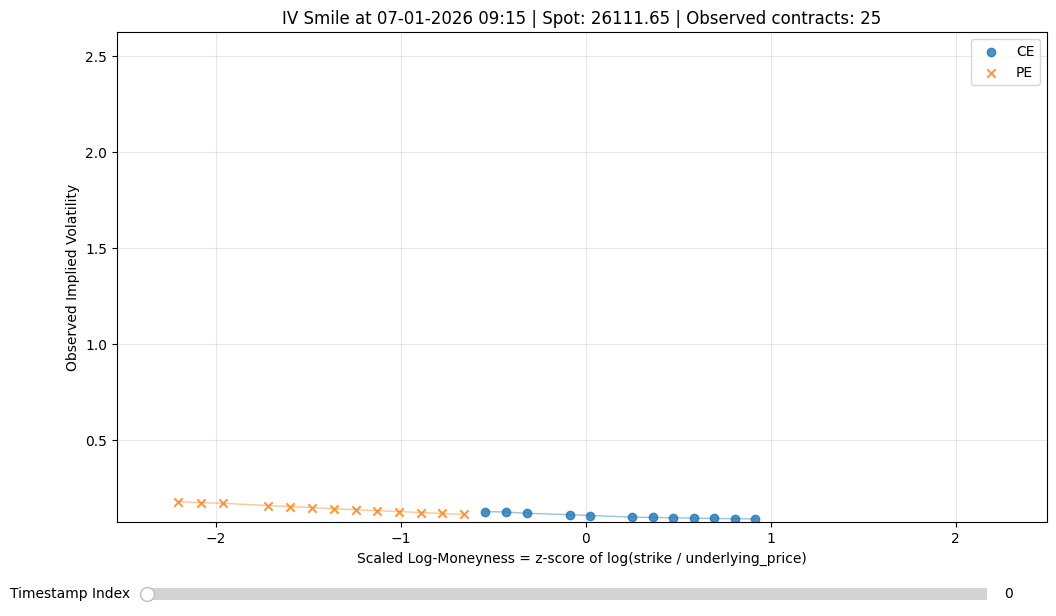

In [6]:
# Precompute each timestamp's data for fast slider updates
by_time = {
    ts: sub.sort_values(["option_type", "scaled_log_moneyness"])
    for ts, sub in plot_data.groupby("datetime")
}

# Fixed axis limits make animation easier to interpret
x_min = plot_data["scaled_log_moneyness"].min() - 0.25
x_max = plot_data["scaled_log_moneyness"].max() + 0.25

y_min = max(0, plot_data["iv"].quantile(0.001) - 0.01)
y_max = plot_data["iv"].quantile(0.999) + 0.01

fig, ax = plt.subplots(figsize=(12, 7))
plt.subplots_adjust(bottom=0.18)

initial_idx = 0
initial_ts = timestamps[initial_idx]
initial = by_time.get(initial_ts, pd.DataFrame())

def split_ce_pe(data):
    ce = data[data["option_type"] == "CE"]
    pe = data[data["option_type"] == "PE"]
    return ce, pe

ce0, pe0 = split_ce_pe(initial)

ce_scatter = ax.scatter(
    ce0["scaled_log_moneyness"],
    ce0["iv"],
    label="CE",
    marker="o",
    alpha=0.8
)

pe_scatter = ax.scatter(
    pe0["scaled_log_moneyness"],
    pe0["iv"],
    label="PE",
    marker="x",
    alpha=0.8
)

# Optional line connections so the smile shape is more visible
ce_line, = ax.plot(
    ce0["scaled_log_moneyness"],
    ce0["iv"],
    alpha=0.45,
    linewidth=1
)

pe_line, = ax.plot(
    pe0["scaled_log_moneyness"],
    pe0["iv"],
    alpha=0.45,
    linewidth=1
)

title = ax.set_title("")
ax.set_xlabel("Scaled Log-Moneyness = z-score of log(strike / underlying_price)")
ax.set_ylabel("Observed Implied Volatility")
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.grid(True, alpha=0.3)
ax.legend()

slider_ax = fig.add_axes([0.15, 0.06, 0.70, 0.035])

time_slider = Slider(
    ax=slider_ax,
    label="Timestamp Index",
    valmin=0,
    valmax=len(timestamps) - 1,
    valinit=initial_idx,
    valstep=1
)

def update_plot(idx):
    idx = int(time_slider.val)
    ts = timestamps[idx]
    data = by_time.get(ts, pd.DataFrame())
    ce, pe = split_ce_pe(data)

    ce_xy = np.column_stack([ce["scaled_log_moneyness"], ce["iv"]]) if len(ce) else np.empty((0, 2))
    pe_xy = np.column_stack([pe["scaled_log_moneyness"], pe["iv"]]) if len(pe) else np.empty((0, 2))

    ce_scatter.set_offsets(ce_xy)
    pe_scatter.set_offsets(pe_xy)

    ce_line.set_data(ce["scaled_log_moneyness"], ce["iv"])
    pe_line.set_data(pe["scaled_log_moneyness"], pe["iv"])

    if len(data):
        spot = data["underlying_price"].iloc[0]
        n_obs = len(data)
    else:
        spot = np.nan
        n_obs = 0

    title.set_text(
        f"IV Smile at {pd.Timestamp(ts).strftime('%d-%m-%Y %H:%M')} | "
        f"Spot: {spot:.2f} | Observed contracts: {n_obs}"
    )

    fig.canvas.draw_idle()

time_slider.on_changed(update_plot)
update_plot(initial_idx)

plt.show()

## 5. Optional: version using raw log-moneyness instead of scaled log-moneyness

Use this if you want the x-axis to be directly interpretable as `log(K/S)` instead of z-score scaled.

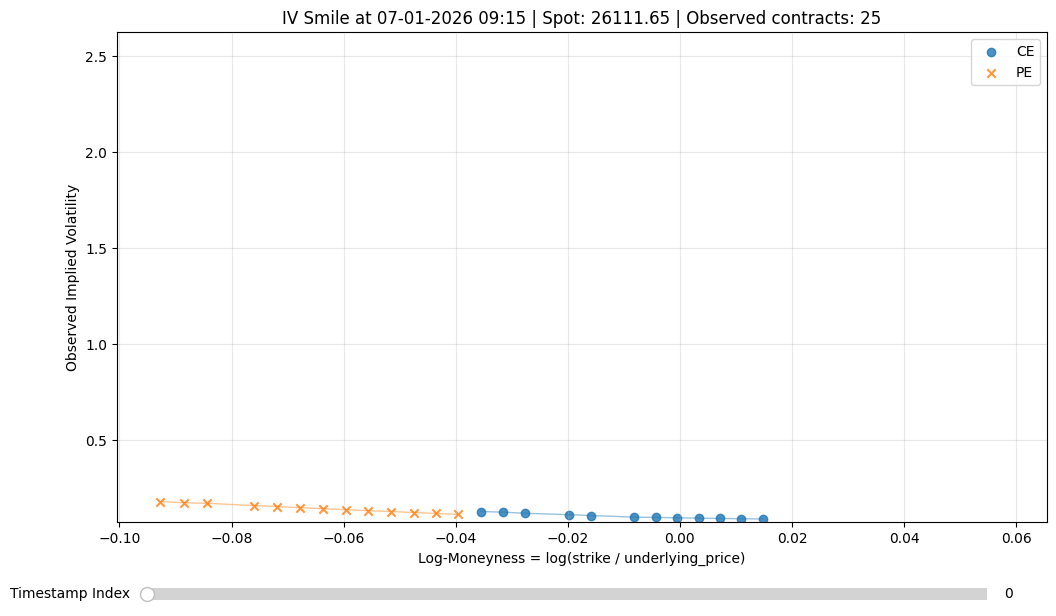

In [7]:
# Optional raw-log-moneyness version.
# Run this cell separately if you prefer raw log(K/S) on the x-axis.

by_time_raw = {
    ts: sub.sort_values(["option_type", "log_moneyness"])
    for ts, sub in plot_data.groupby("datetime")
}

x_min_raw = plot_data["log_moneyness"].min() - 0.005
x_max_raw = plot_data["log_moneyness"].max() + 0.005

fig_raw, ax_raw = plt.subplots(figsize=(12, 7))
plt.subplots_adjust(bottom=0.18)

initial_ts = timestamps[0]
initial = by_time_raw.get(initial_ts, pd.DataFrame())
ce0 = initial[initial["option_type"] == "CE"]
pe0 = initial[initial["option_type"] == "PE"]

ce_s = ax_raw.scatter(ce0["log_moneyness"], ce0["iv"], label="CE", marker="o", alpha=0.8)
pe_s = ax_raw.scatter(pe0["log_moneyness"], pe0["iv"], label="PE", marker="x", alpha=0.8)

ce_l, = ax_raw.plot(ce0["log_moneyness"], ce0["iv"], alpha=0.45, linewidth=1)
pe_l, = ax_raw.plot(pe0["log_moneyness"], pe0["iv"], alpha=0.45, linewidth=1)

title_raw = ax_raw.set_title("")
ax_raw.set_xlabel("Log-Moneyness = log(strike / underlying_price)")
ax_raw.set_ylabel("Observed Implied Volatility")
ax_raw.set_xlim(x_min_raw, x_max_raw)
ax_raw.set_ylim(y_min, y_max)
ax_raw.grid(True, alpha=0.3)
ax_raw.legend()

slider_ax_raw = fig_raw.add_axes([0.15, 0.06, 0.70, 0.035])
slider_raw = Slider(
    ax=slider_ax_raw,
    label="Timestamp Index",
    valmin=0,
    valmax=len(timestamps) - 1,
    valinit=0,
    valstep=1
)

def update_raw(_):
    idx = int(slider_raw.val)
    ts = timestamps[idx]
    data = by_time_raw.get(ts, pd.DataFrame())

    ce = data[data["option_type"] == "CE"]
    pe = data[data["option_type"] == "PE"]

    ce_xy = np.column_stack([ce["log_moneyness"], ce["iv"]]) if len(ce) else np.empty((0, 2))
    pe_xy = np.column_stack([pe["log_moneyness"], pe["iv"]]) if len(pe) else np.empty((0, 2))

    ce_s.set_offsets(ce_xy)
    pe_s.set_offsets(pe_xy)

    ce_l.set_data(ce["log_moneyness"], ce["iv"])
    pe_l.set_data(pe["log_moneyness"], pe["iv"])

    spot = data["underlying_price"].iloc[0] if len(data) else np.nan
    n_obs = len(data)

    title_raw.set_text(
        f"IV Smile at {pd.Timestamp(ts).strftime('%d-%m-%Y %H:%M')} | "
        f"Spot: {spot:.2f} | Observed contracts: {n_obs}"
    )

    fig_raw.canvas.draw_idle()

slider_raw.on_changed(update_raw)
update_raw(None)

plt.show()